In [174]:
import sys
sys.path.append(r"C:\nirfasterFF")
import nirfasterff as ff # ff is short for fast and furious
import numpy as np
import matplotlib.pyplot as plt

In [175]:

mua = 0.01
mus = 0.33 # approx same as musp here
ri = 1.33
mua_pert_percent = 0.01
mus_pert_percent = 0.01


Meshing parameters

In [176]:
vol = 2 * np.ones((60,60,60))
vol = vol.astype(np.uint8)

meshing_params = ff.utils.MeshingParams(
    xPixelSpacing=0.5,  # Finer voxel resolution
    yPixelSpacing=0.5,
    SliceThickness=0.5,
    general_cell_size=1.0,  # Smaller elements
    cell_radius_edge=2.0,  # Better element quality
    facet_size=1.5,  # More refined surface
    facet_distance=1.0
)
# call the mesher
ele, nodes = ff.meshing.RunCGALMeshGenerator(vol, opt = meshing_params)

Create the main mesh

In [177]:
mesh = ff.base.stndmesh()
mesh.from_solid(ele, nodes)

# for each row, [region, mua(mm-1), musp(mm-1), ri]
prop = np.array([[1, mua, mus, ri]])
mesh.set_prop(prop)
mesh.kappa = 1 / (3*(mesh.mua + mesh.mus))
# set link (source-detector pairs)
mesh.link = np.array([[1,1,1]],dtype=np.int32)
# optodes
mesh.source = ff.base.optode(np.array([5,30,60]))
mesh.meas = ff.base.optode(np.array([55,30,60]))
# move them (for non-fixed) and calculate the integration function
mesh.touch_optodes()

touching sources
touching detectors


Create grid space

In [178]:
xgrid = np.arange(0., 60, 0.5)
ygrid = np.arange(0., 60, 0.5)
zgrid = np.arange(0., 60, 0.5)

mesh.gen_intmat(xgrid, ygrid, zgrid)

Define Ultrasound(US) parameters

In [179]:
wv = 785 #nm
k0 = 2*np.pi / (wv/1e6)

#US parameters
fa = 5e6  # frequency of US (Hz)
va = 1480*1e3   # acoustic wave velocity
ka = 2*np.pi / (va/(fa))  # va=1480m/s
wa = 2*np.pi*fa   # 2*pi*fa
ltr = 1/mesh.mus
rho = 1000*1e-9   # for water
eta = 0.32       # for water
Sa = 1.
phi = 0.
P0 = 1e5  # US pressue(pascal)
tau = 0.5*(1/fa)  #T/2

Define US size, shape, position, and select nodes that falls inside the US-field

In [180]:
# Define UltraSound position
x_cen_us,y_cen_us,z_cen_us = [30,30,30] #centre of the US , z-pos is measured from bottom surface(starting from 0) to top surface here in the mesh space
                               #(although in general terminology, its expressed as depth from top surface)

# For cylinder-shaped US-focus
# dist = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_us)) + np.square((mesh.nodes[:,1]-y_cen_us)) + np.square((mesh.nodes[:,2]-z_cen_us)))
# height = 7  #height of cylinder
# dia = 5     #diameter of cylinder
# ind= np.zeros(len(mesh.nodes))

# for i in range(len(mesh.nodes)):     # selecting nodes for Cylindrical US: Z-axis aligned   
#     if mesh.nodes[i,2]>(z_cen_us-height/2) and mesh.nodes[i,2]<(z_cen_us+height/2) and np.sqrt((mesh.nodes[i,0]-x_cen_us)**2+(mesh.nodes[i,1]-y_cen_us)**2) < dia/2 :
#         ind[i] = dist[i] 

# For sperically-shaped US-focus
dia = 8
dist = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_us)) + np.square((mesh.nodes[:,1]-y_cen_us)) + np.square((mesh.nodes[:,2]-z_cen_us)))
ind= np.zeros(len(mesh.nodes)) 
ind = dist < dia/2


us_selection = np.argwhere(ind != 0)

Assign pressure values to selected US-nodes

In [181]:
p0 = np.zeros(len(mesh.mua))
p0[us_selection] = P0/1e3           #assigning a pressure value to the selected nodes within the cylindrical vol(also converting into N/mm2)

ht = (np.square((p0*k0*mesh.ri)/(ka*rho*va*va))) * (1-np.cos(wa*tau)) * ( (np.square(eta))*(ka*ltr)*(np.arctan(ka*ltr)) + Sa*Sa/3 - 2*eta*Sa/np.cos(phi))

Create the US-Mesh

In [182]:
# making a duplicate of main mesh for creating the 'US-perturbed-mesh'
mesh1 = ff.base.stndmesh()
mesh1.from_copy(mesh)

mesh1.mua = mesh.mua + mesh.mus*ht    # mesh1 is now the US-perturbed mesh, 
                                      # mesh1 will be used in all subsequent cases below which involves US.
mesh1.kappa = 1.0 / (3.0*(mesh1.mua + mesh1.mus))

#### TEST 1: comparing [Perturbation method-doD    vs     mua-jacobian method-doD] for US-perturbed mesh

In [183]:
#Scan parameters
start = 10
stop = 50
step = 10

Scanning an absorber inclusion along z-axis with US-pos fixed and analysing the error of [Perturbation vs Jacobian method] for each inclusion position

In [184]:

J_mua_us = mesh1.jacobian(normalize=False)[0]    # US-mua-Jacobian  # run the code block where mesh1 is initialized - (1, 1728000)


# creating duplicate of mesh1 for measuring US-perturbed-perturbation-model doD
mesh2 = ff.base.stndmesh()


doD_mua_pert = np.zeros(stop+1)
doD_mua_jacobian = np.zeros(stop+1)

print('\n')

for i in range(start,stop+1,step):
   mesh2.from_copy(mesh1)       # mua of mesh2 is same as mesh1.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh1

   # add a spherical absorption inclusion in mesh2
   dia_ab =  6   #diameter of spherical absorber
   x_cen_ab,y_cen_ab,z_cen_ab = [30,30,i]      #centre of the absorber
   dist_ab = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_ab)) + np.square((mesh.nodes[:,1]-y_cen_ab)) + np.square((mesh.nodes[:,2]-z_cen_ab)))
                                             #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes' 
   ind_ab = dist_ab < dia_ab/2
   mua_selection = np.where(ind_ab)           #of all node points, this is the selection of nodes where the absorber inclusion exists

   


   # Modify the mua-map of mesh2(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   if i!=z_cen_us:
      mesh2.mua[mua_selection] = mesh2.mua[mua_selection] + 0.01*mesh2.mua[mua_selection] #(1 + mua_pert_percent)*mesh2.mua[mua_selection] 
      print(f"mesh2.mua at absorber position z={60-i}: ",mesh2.mua[mua_selection][0])
   if i==z_cen_us:                                 #only if the inclusion coincides with the US-position!
      mesh2.mua[mua_selection] = mesh2.mua[mua_selection] + 0.01*mesh2.mua[mua_selection] - 0.01*mesh2.mus[mua_selection]*ht[mua_selection] 
      print(f"mesh2.mua at absorber position z={60-i}: ",mesh2.mua[mua_selection][0])
   mesh2.kappa[mua_selection] = 1.0 / (3.0*(mesh2.mua[mua_selection] + mesh2.mus[mua_selection]))
   data_mesh1 = mesh1.femdata(0)[0]
   data_mesh2 = mesh2.femdata(0)[0]
   doD_mua_pert[i] = ((data_mesh2.amplitude) - (data_mesh1.amplitude)).item()
   


   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mua_selection] = mua_pert_percent*mesh2.mua[mua_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmua = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mua_jacobian[i] = (J_mua_us @ dmua).item()


   #Compare
   
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {60-i} mm:", doD_mua_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {60-i} mm:", doD_mua_jacobian[i])
   print('percentage error:' , abs((doD_mua_jacobian[i]-doD_mua_pert[i])/doD_mua_pert[i])*100)
   print('\n')

Calculating direct field...
Calculating adjoint field...
Integrating...


mesh2.mua at absorber position z=50:  0.0101
doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: -1.2817784646654003e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: -1.3408991311991314e-13
percentage error: 4.612393495717234


mesh2.mua at absorber position z=40:  0.0101
doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: -1.3549604058073325e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: -1.3962815214276649e-12
percentage error: 3.049617940364229


mesh2.mua at absorber position z=30:  0.013538109199380585
doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -9.98808507855107e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: -1.3525784011829975e-11
percentage error: 35.41919102066864


mesh2.mua at absorber position z=20:  0.0101
doD from US-perturbed-absorption-blob-perturbation model at

In [ ]:
print(mesh1.mua[us_selection])

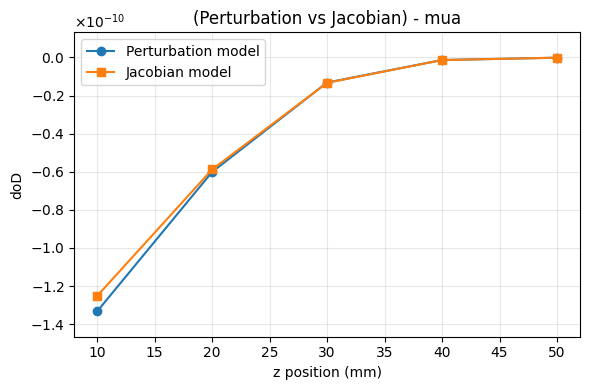

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Indices where values exist
z_positions = [10, 20, 30, 40, 50]

# Extract values at those indices
x = np.array(z_positions, dtype=float)
y_pert = np.array([-1.3330624923003823e-10,-6.01134603328151e-11,-1.3174794896518284e-11,-1.3316994326493896e-12,-1.2932868726208487e-13], dtype=float)
y_jac  = np.array([-1.2523296155294787e-10,-5.879407122838562e-11,-1.3310357577699792e-11,-1.3719850993024005e-12,-1.35325292245973e-13], dtype=float)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model')
plt.plot(x, y_jac, marker='s', linewidth=1.5, label='Jacobian model')

# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

# Zoom in around the min/max range with 10% padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

plt.xlabel('z position (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mua')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### TEST 2: comparing [Perturbation method-doD    vs     mus-jacobian method-doD] for US-perturbed mesh

Scanning an scatterer inclusion along z-axis with US-pos fixed and analysing the error of [Perturbation vs Jacobian method] for each inclusion position

In [ ]:
#Scan parameters
start = 10
stop = 50
step = 10

In [161]:
J_mus_us = mesh1.jacobian(normalize=False,mus=True)[0]    # US-mus-Jacobian 
J_mus_us = J_mus_us[:,:xgrid.size * ygrid.size * zgrid.size]    #(1, 1728000) # extracting just the mus part of the jacobian

# creating duplicate of mesh1 for measuring US-perturbed-perturbation-model doD
mesh3 = ff.base.stndmesh()


doD_mus_pert = np.zeros(stop+1)
doD_mus_jacobian = np.zeros(stop+1)

for i in range(start,stop+1,step):
   mesh3.from_copy(mesh1)       # mua of mesh3 is same as mesh1.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh1

   # add a spherical scatterer inclusion in mesh3
   dia_sc =  6   #diameter of spherical scatterer
   x_cen_sc,y_cen_sc,z_cen_sc = [30,30,i]      #centre of the scatterer
   dist_sc = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_sc)) + np.square((mesh.nodes[:,1]-y_cen_sc)) + np.square((mesh.nodes[:,2]-z_cen_sc)))
                                             #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes' 
   ind_sc = dist_sc < dia_sc/2
   mus_selection = np.where(ind_sc)          #of all node points, this is the selection of nodes where the absorber inclusion exists

   


   # Modify the mus-map of mesh3(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   mesh3.mus[mus_selection] = mesh3.mus[mus_selection] + mus_pert_percent*mesh3.mus[mus_selection]
   if i==z_cen_us:                                 #only if the inclusion coincides with the US-position!
      mesh3.mua[mus_selection] = mesh3.mua[mus_selection] + mesh3.mus[mus_selection]*ht[mus_selection]   # since, for nodes inside the US-focus, mua also depends on mus
   mesh3.kappa[mus_selection] = 1.0 / (3.0*(mesh3.mua[mus_selection] + mesh3.mus[mus_selection]))
   data_mesh1 = mesh1.femdata(0)[0]
   data_mesh3 = mesh3.femdata(0)[0]
   doD_mus_pert[i] = ((data_mesh3.amplitude) - (data_mesh1.amplitude)).item()
     


   # Now calculate doD using the Jacobian method
   # creating the difference in scattering for selected nodes(to be multiplied with mus-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mus_selection] = mus_pert_percent*mesh3.mus[mus_selection]         # this is the effective difference in scattering (in mesh-space). a 1% change in 'just scattering' 
   dmus = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mus_jacobian[i] = (J_mus_us @ dmus).item()


   #Compare
   print('\n')
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {60-i} mm:", doD_mus_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {60-i} mm:", doD_mus_jacobian[i])
   print('percentage error:' , abs((doD_mus_jacobian[i]-doD_mus_pert[i])/doD_mus_pert[i])*100)



Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: 1.502902499360279e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: 1.5298486841193527e-13
percentage error: 1.7929429733827367


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: 8.764898482603123e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: 8.915978726317645e-13
percentage error: 1.7236964468486566


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -3.3731269300366376e-10
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: 2.7944197976113806e-13
percentage error: 100.08284360048026


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -6.334077040739e-11
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -6.456935977433712e-11
percentage error: 1.939650179568684


doD from US-perturbed-absorption-blo

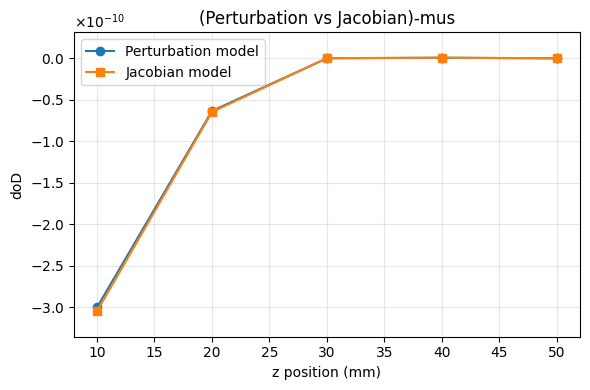

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Indices where values exist
z_positions = [10, 20, 30, 40, 50]

# Extract values at those indices
x = np.array(z_positions, dtype=float)
y_pert = np.array([-3.002399118726207e-10,-6.334315391299907e-11,2.424891729928047e-13,8.763379900759462e-13,1.4880248378626253e-13], dtype=float)
y_jac  = np.array([-3.049404398708365e-10,-6.457596094383557e-11,2.7625100576758425e-13,8.913843443103818e-13,1.5144678179856805e-13], dtype=float)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model')
plt.plot(x, y_jac, marker='s', linewidth=1.5, label='Jacobian model')

# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

# Zoom in around the min/max range with 10% padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

plt.xlabel('z position (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mus')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
